# 1- Problema: Detectar inadimplência de cartão de credito

## 1-1 Explicação da base de dados

### Traduzido para Português

Fonte: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients
Informações sobre o Conjunto de Dados

Esta pesquisa utilizou uma variável binária, inadimplência (Sim = 1, Não = 0), como variável resposta. Este estudo revisou a literatura e utilizou as seguintes 23 variáveis ​​como variáveis ​​explicativas:

LIMIT_BAL: Valor do crédito concedido (em NT$): inclui tanto o crédito individual ao consumidor quanto o crédito familiar (suplementar).

SEX: Sexo (1 = masculino; 2 = feminino).

EDUCATION: Escolaridade (1 = pós-graduação; 2 = ensino superior; 3 = ensino médio; 4 = outros).

MARRIAGE: Estado civil (1 = casado(a); 2 = solteiro(a); 3 = outros).

AGE: Idade (em anos).

PAY_1 a PAY_6: Histórico de pagamentos. Acompanhamos os registros de pagamentos mensais anteriores (de abril a setembro de 2005) da seguinte forma: PAY_1 = situação do pagamento em setembro de 2005; PAY_2 = situação do pagamento em agosto de 2005; ... PAY_6 = situação de pagamento em abril de 2005. A escala de medição da situação de pagamento é: -1 = pago em dia; 1 = atraso de um mês; 2 = atraso de dois meses; ...; 8 = atraso de oito meses; 9 = atraso de nove meses ou mais.

BILL_AMT1-BILL_AMT6: Valor da fatura (dólares taiwaneses). BILL_AMT1 = valor da fatura em setembro de 2005; BILL_AMT2 = valor da fatura em agosto de 2005; ...; BILL_AMT6 = valor da fatura em abril de 2005.

PAY_AMT1-PAY_AMT6: Valor do pagamento anterior (dólares taiwaneses). PAY_AMT1 = valor pago em setembro de 2005; PAY_AMT2 = valor pago em agosto de 2005; ...; PAY_AMT6 = valor pago em abril de 2005.


### Objetivo

Prever a inadimplência de clientes de cartão de crédito no mês subsequente utilizando modelos de machine learning com melhor desempenho.

# 2- Exploração dos Dados

## 2-1 Imports

In [ ]:
import os
import pandas as pd

## Importar dados de base publica do google drive

file_id = '1iZFmr0ys8g_3BGc3jlE8UQ8hNFlOmY5s'

url = f'https://drive.google.com/uc?export=download&id={file_id}'


df = pd.read_csv(url)
display(df.head())

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


##2-2 Exploração dos features

### 2-2-1 - Ponto importante - Distribuição do target

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_1                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [ ]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


Data set sem nulos e totalmente transformado em números

In [ ]:
## Apresentação da distribuição do target: default payment next month:
target_distribution = df['default payment next month'].value_counts()
display(target_distribution)
target_percentage = df['default payment next month'].value_counts(normalize=True) * 100
print('\nPercentage Distribution:')
display(target_percentage)

,count
default payment next month,
0,23364
1,6636



Percentage Distribution:


,proportion
default payment next month,
0,77.88
1,22.12


0= Adimplente e 1 = Inadimplente
Sendo a base desbalanceada conforme distribuição acima

### 2-2-2 - Conferindo features categóricas conforme documentação

In [ ]:
# Tirando o id do df
df = df.drop('ID', axis=1)

#### Feature: SEX

In [ ]:
## Conferindo se as variáveis categoricas estão condizentes com documentação
## Conferiando se a feature SEX só possuí 1 e 2 e conferindo distribuição
print(df['SEX'].unique())
SEX_distribution = df['SEX'].value_counts()
display(SEX_distribution)
SEX_percentage = df['SEX'].value_counts(normalize=True) * 100
print('\nPercentage Distribution:')
display(SEX_percentage)
#SEX: Sexo (1 = masculino; 2 = feminino).

[2 1]


,count
SEX,
2,18112
1,11888



Percentage Distribution:


,proportion
SEX,
2,60.373333
1,39.626667


#### Feature: EDUCATION

In [ ]:
#Conferindo se EDUCATION está condizente com:
#EDUCATION: Escolaridade (1 = pós-graduação; 2 = ensino superior; 3 = ensino médio; 4 = outros)
#cria o unique do education e imprime de forma crescente
education_unique = pd.DataFrame(sorted(df['EDUCATION'].unique()), columns=['EDUCATION'])
display(education_unique)

,EDUCATION
0,0
1,1
2,2
3,3
4,4
5,5
6,6


In [ ]:
# Transformar no df os valores 0, 5 E 6 PARA 4 da coluna EDUCATION, uma vez que esses valores não estão na documentação, se transformarão em "outros"
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
#

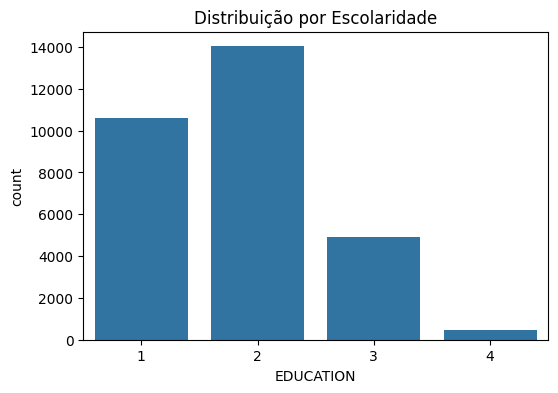

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='EDUCATION', data=df)
plt.title('Distribuição por Escolaridade')
plt.show()

Escolaridade: 1 = pós-graduação; 2 = ensino superior; 3 = ensino médio e  4 =
outros

#### Feature: MARRIAGE

In [ ]:
#Confere valores da feature MARRIAGE
#MARRIAGE: Estado civil (1 = casado(a); 2 = solteiro(a); 3 = outros).
print(df['MARRIAGE'].unique())

[1 2 3 0]


In [ ]:
# Transforma valor 0 para 3 (outros) da feature MARRIAGE
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

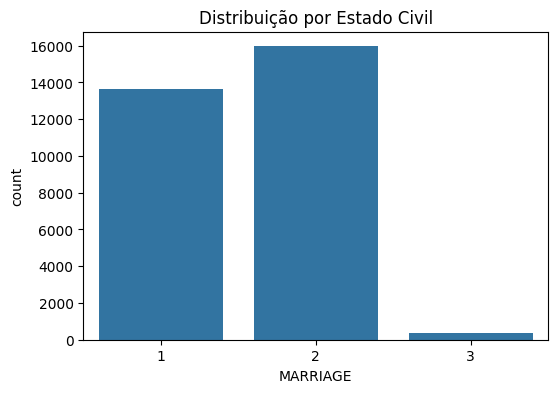

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='MARRIAGE', data=df)
plt.title('Distribuição por Estado Civil')
plt.show()

Estado civil: 1 = casado; 2 = solteiro e 3 = outros

#### Feature: AGE

In [ ]:
#print AGE unique ordenada
AGE_unique = pd.DataFrame(sorted(df['AGE'].unique()), columns=['AGE'])
display(AGE_unique)

,AGE
0,21
1,22
2,23
3,24
4,25
5,26
6,27
7,28
8,29
9,30


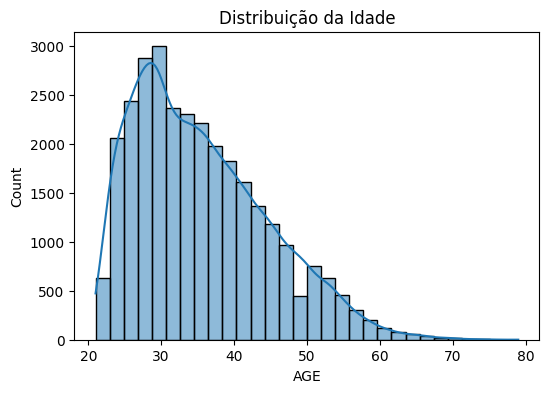

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['AGE'], bins=30, kde=True)
plt.title('Distribuição da Idade')
plt.show()

#### Feature: Limite de Crédito

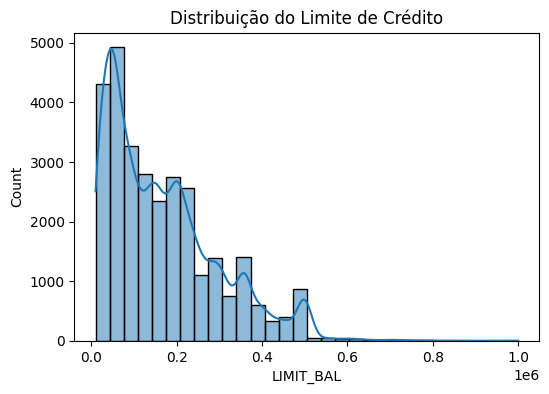

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['LIMIT_BAL'], bins=30, kde=True)
plt.title('Distribuição do Limite de Crédito')
plt.show()

####Feature: PAYs

In [ ]:
## Apresentar unique de todas variáveis PAY
for i in range(1, 7):
    print(f'PAY_{i} unique: {df[f"PAY_{i}"].unique()}')
# finalizar laço



PAY_1 unique: [ 2 -1  0 -2  1  3  4  8  7  5  6]
PAY_2 unique: [ 2  0 -1 -2  3  5  7  4  1  6  8]
PAY_3 unique: [-1  0  2 -2  3  4  6  7  1  5  8]
PAY_4 unique: [-1  0 -2  2  3  4  5  7  6  1  8]
PAY_5 unique: [-2  0 -1  2  3  5  4  7  8  6]
PAY_6 unique: [-2  2  0 -1  3  6  4  7  8  5]


In [ ]:
# A documentação não menciona valores menores que -1, e não menciona valor 0
#Para investigar esses registro, irei printar a linha com as features de valores PAY,BILL_AMT e PAY
DF_2menos = df[(df['PAY_1'] == -2) & (df['PAY_2'] == -2) & (df['PAY_3'] == -2)][[
    'PAY_1','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6',
    'default payment next month'
]]
#distribuição de target no df_2menos com valores e percentual
# Meses mais recentes apontados com -2
display("Meses mais recentes apontados com -2")
display(DF_2menos['default payment next month'].value_counts())
display(DF_2menos['default payment next month'].value_counts(normalize=True) * 100)
DF_2menos.head(10)
#df[df['PAY_1'] == 0].head(10)

'Meses mais recentes apontados com -2'

,count
default payment next month,
0,2072
1,329


,proportion
default payment next month,
0,86.297376
1,13.702624


,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
9,-2,-2,-2,-2,-1,-1,0,0,0,0,13007,13912,0,0,0,13007,1122,0,0
23,-2,-2,-2,-2,-2,-2,5512,19420,1473,560,0,0,19428,1473,560,0,0,1128,1
33,-2,-2,-2,-2,-2,-2,10929,4152,22722,7521,71439,8981,4152,22827,7521,71439,981,51582,0
34,-2,-2,-2,-2,-2,-2,13709,5006,31130,3180,0,5293,5006,31178,3180,0,5293,768,0
45,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1
52,-2,-2,-2,-2,-2,-2,13465,7867,7600,11185,3544,464,7875,7600,11185,3544,464,0,0
55,-2,-2,-2,-2,-2,-2,1905,3640,162,0,151,2530,3640,162,0,151,2530,0,0
65,-2,-2,-2,-1,2,2,152519,148751,144076,8174,8198,7918,0,0,8222,300,0,1000,1
92,-2,-2,-2,-2,-2,-2,-2000,5555,0,0,0,0,7555,0,0,0,0,0,0
100,-2,-2,-2,-2,-2,-2,672,10212,850,415,100,1430,10212,850,415,100,1430,0,0


In [ ]:
# A documentação não menciona valores menores que -1, e não menciona valor 0
#Para investigar esses registro, irei printar a linha com as features de valores PAY,BILL_AMT e PAY
DF_zero = df[(df['PAY_1'] == 0) & (df['PAY_2'] == 0) & (df['PAY_3'] == 0)][[
    'PAY_1','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6',
    'default payment next month'
]]
#distribuição de target no df_2menos com valores e percentual
# Meses mais recentes apontados com -0
display("Meses mais recentes apontados com 0")
display(DF_zero['default payment next month'].value_counts())
display(DF_zero['default payment next month'].value_counts(normalize=True) * 100)
DF_zero.head(10)
#df[df['PAY_1'] == 0].head(10)

'Meses mais recentes apontados com 0'

,count
default payment next month,
0,11219
1,1506


,proportion
default payment next month,
0,88.165029
1,11.834971


,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
2,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,0,0,0,0,0,0,64400,57069,57608,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,0,0,0,0,0,0,367965,412023,445007,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
14,0,0,0,0,0,0,70887,67060,63561,59696,56875,55512,3000,3000,3000,3000,3000,3000,0
17,0,0,0,-1,-1,-1,253286,246536,194663,70074,5856,195599,10358,10000,75940,20000,195599,50000,0
20,0,0,0,0,0,-1,38358,27688,24489,20616,11802,930,3000,1537,1000,2000,930,33764,0
24,0,0,0,-1,0,0,4744,7070,0,5398,6360,8292,5757,0,5398,1200,2045,2000,0
25,0,0,0,0,0,0,47620,41810,36023,28967,29829,30046,1973,1426,1001,1432,1062,997,0
27,0,0,0,0,0,0,22541,16138,17163,17878,18931,19617,1300,1300,1000,1500,1000,1012,0


In [ ]:
DF_atraso = df[(df['PAY_1'] == 8) & (df['PAY_2'] == 7) & (df['PAY_3'] == 6)][[
    'PAY_1','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6',
    'default payment next month'
]]
#distribuição de target no df_atraso com valores e percentual
# Meses mais recentes apontados com atraso
display("Meses mais recentes apontados com 8, 7 e 6")
display(DF_atraso['default payment next month'].value_counts())
display(DF_atraso['default payment next month'].value_counts(normalize=True) * 100)
DF_atraso.head(10)
#df[df['PAY_1'] == 0].head(10)

'Meses mais recentes apontados com 8, 7 e 6'

,count
default payment next month,
1,11
0,8


,proportion
default payment next month,
1,57.894737
0,42.105263


,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
649,8,7,6,5,4,3,21075,20795,20206,19617,18737,18148,0,0,0,0,0,0,0
749,8,7,6,5,4,3,37647,37102,36238,36374,35229,34365,0,0,1000,0,0,3000,1
831,8,7,6,5,4,3,24310,23987,23353,22719,21796,21162,0,0,0,0,0,0,0
981,8,7,6,5,4,3,34423,33952,33165,32391,31332,30558,0,0,0,0,0,0,0
2362,8,7,6,5,4,3,24348,24025,23391,22757,21834,21200,0,0,0,0,0,0,0
2916,8,7,6,5,4,3,43340,42619,35381,31539,27409,23567,0,0,0,0,0,300,0
4336,8,7,6,5,4,3,377779,372355,365250,358145,352121,346216,0,0,0,0,0,0,1
4387,8,7,6,5,4,3,112662,111077,108539,106001,103816,101878,0,0,0,0,0,0,1
4444,8,7,6,5,4,3,110072,108478,105931,104554,102360,100413,0,0,1170,0,0,0,0
6753,8,7,6,5,4,3,16942,16721,16193,16445,15624,15096,0,0,780,0,0,0,1


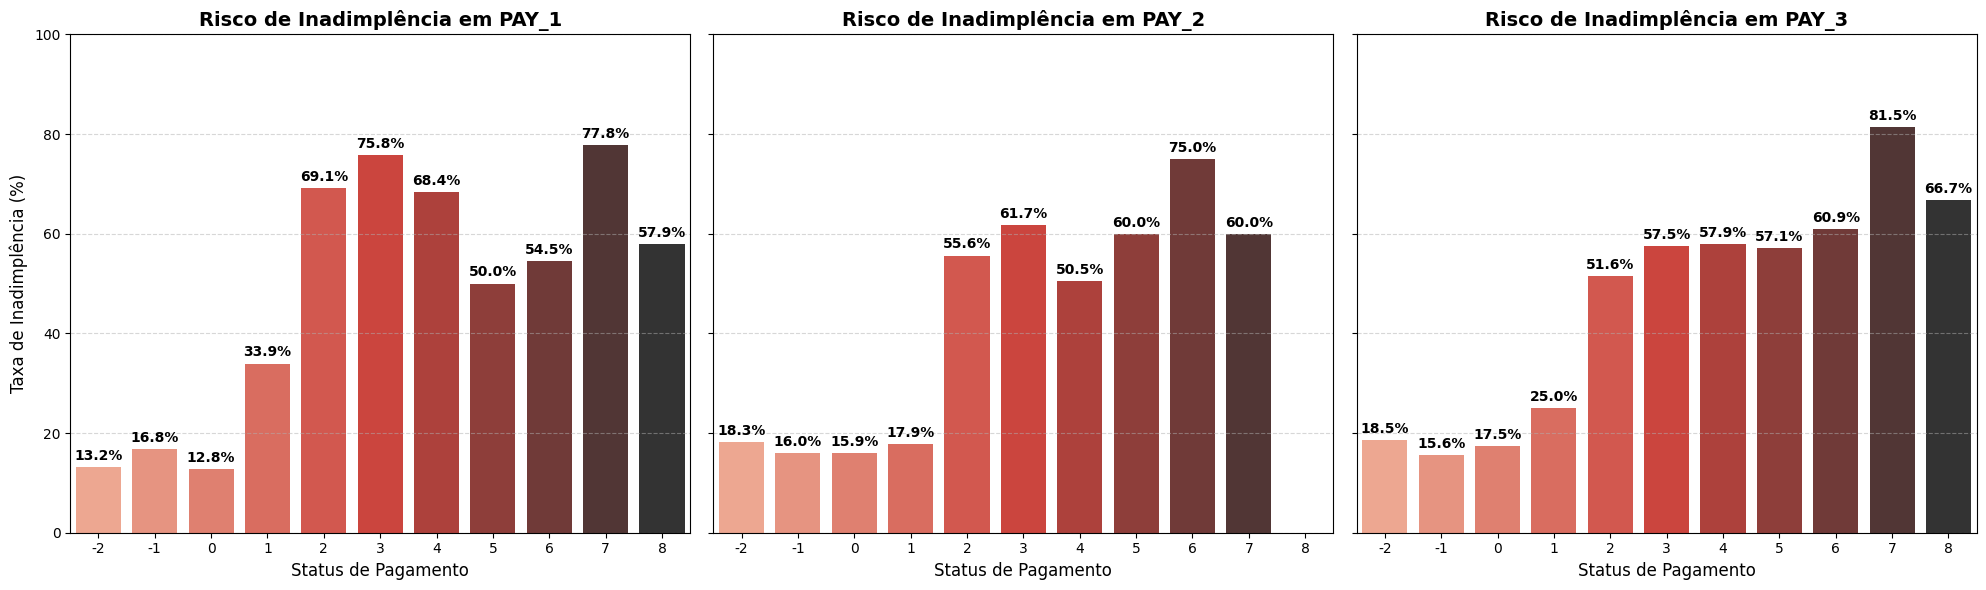

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o "quadro" com 1 linha e 3 colunas
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# Lista das colunas que queremos comparar
colunas_pay = ['PAY_1', 'PAY_2', 'PAY_3']
target = 'default payment next month'

for i, col in enumerate(colunas_pay):
    # 1. Calculando a taxa de inadimplência
    taxa_default = df.groupby(col)[target].mean() * 100

    # 2. Criando o gráfico de barras - o segredo é o parâmetro ax=axes[i]
    sns.barplot(
        x=taxa_default.index,
        y=taxa_default.values,
        ax=axes[i],
        hue=taxa_default.index, # Adicionado para evitar avisos de versões novas
        palette='Reds_d',
        legend=False
    )

    # 3. Customização de cada gráfico individualmente usando axes[i]
    axes[i].set_title(f'Risco de Inadimplência em {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Status de Pagamento', fontsize=12)

    # Apenas o primeiro gráfico ganha o rótulo do eixo Y para não poluir
    if i == 0:
        axes[i].set_ylabel('Taxa de Inadimplência (%)', fontsize=12)
    else:
        axes[i].set_ylabel('')

    axes[i].set_ylim(0, 100)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

    # 4. Adicionando os rótulos de porcentagem sobre as barras do gráfico atual
    for p in axes[i].patches:
        height = p.get_height()
        if height > 0: # Só desenha se houver valor
            axes[i].annotate(f'{height:.1f}%',
                             (p.get_x() + p.get_width() / 2., height),
                             ha='center', va='center', xytext=(0, 8),
                             textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

#### Os registros 0 e -2 demonstram que são registros positivos, onde o percentual de adimplentes aumenta ao filtrar registros nos últimos meses desse tipo, ao contrário de quando filtros registros de atraso.

### 2-2-3 Relações de Features com Target

In [ ]:
# Correlação com a variável target ('default payment next month')
correlation_with_target = df.corr()['default payment next month'].sort_values(ascending=False)
display(correlation_with_target)

,default payment next month
default payment next month,1.000000
PAY_1,0.324794
PAY_2,0.263551
PAY_3,0.235253
PAY_4,0.216614
PAY_5,0.204149
PAY_6,0.186866
EDUCATION,0.033842
AGE,0.013890
BILL_AMT6,-0.005372


A correlação evidenciou que as variáveis relacionadas ao histórico de pagamento (PAY_1 a PAY_6) apresentam maior relação com a inadimplência, indicando que atrasos anteriores são fortes preditores de risco

In [ ]:
df.groupby('default payment next month')['LIMIT_BAL'].mean()

,LIMIT_BAL
default payment next month,
0,178099.726074
1,130109.656420


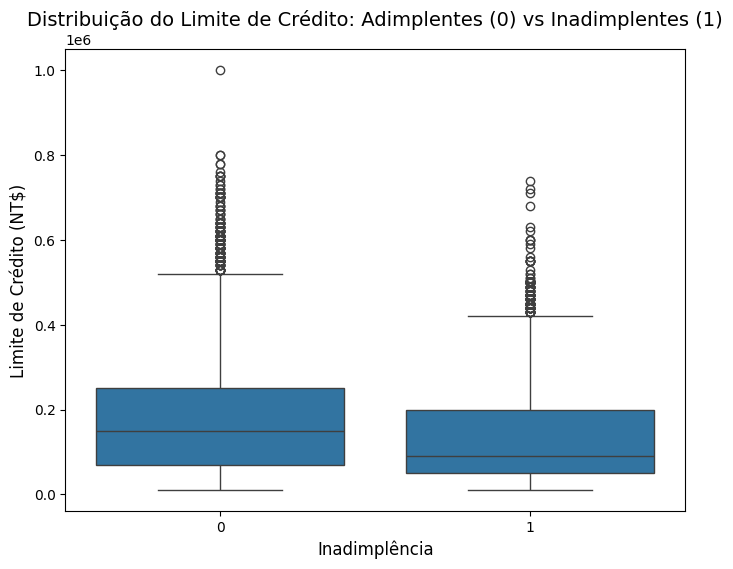

In [ ]:
# Distribuição de Limite de Crédito por Target
plt.figure(figsize=(8, 6))
sns.boxplot(x='default payment next month', y='LIMIT_BAL', data=df)
plt.title('Distribuição do Limite de Crédito: Adimplentes (0) vs Inadimplentes (1)', fontsize=14)
plt.xlabel('Inadimplência', fontsize=12)
plt.ylabel('Limite de Crédito (NT$)', fontsize=12)
plt.show()

Clientes inadimplentes tem a média de limite mais baixa que clientes adimplentes

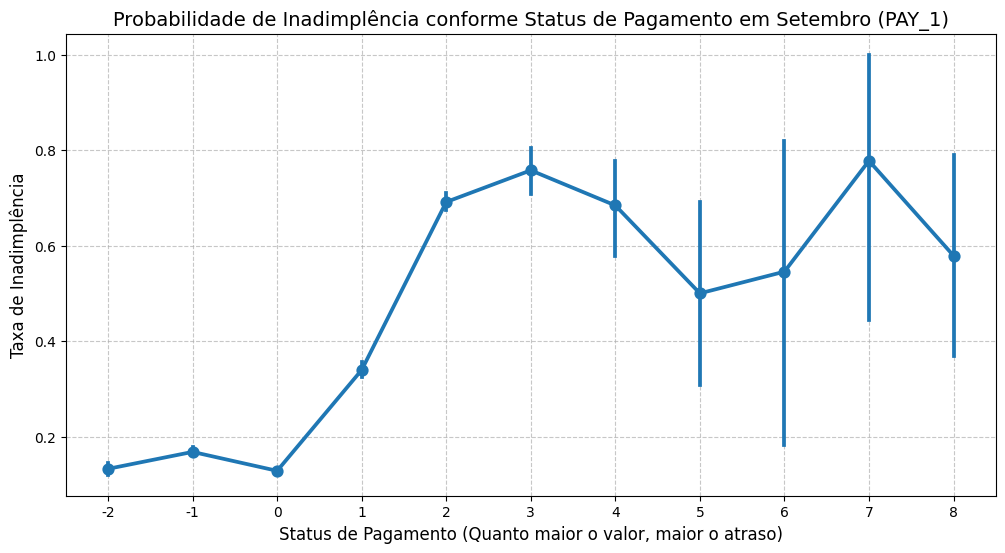

In [ ]:
# Relação entre Status de Pagamento (Setembro/Pay_1 com maior correlação) e Inadimplência
plt.figure(figsize=(12, 6))
sns.pointplot(x='PAY_1', y='default payment next month', data=df)
plt.title('Probabilidade de Inadimplência conforme Status de Pagamento em Setembro (PAY_1)', fontsize=14)
plt.xlabel('Status de Pagamento (Quanto maior o valor, maior o atraso)', fontsize=12)
plt.ylabel('Taxa de Inadimplência', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Observa-se crescimento exponencial no risco de crédito quando o cliente atinge dois meses de atraso (valor 2), onde a taxa de inadimplência salta de aproximadamente 10% (clientes em dia) para cerca de 70% - (aqui eu pedi uma ajuda da IA pra plotar uma boa visualização, mais acho que ta meio ruim explicar, avaliar uma forma melhor de apresentar esses dados)

#3 - Pré-Processamento dos dados

In [ ]:
# Separação entre X e Y (features e target)
X = df.drop('default payment next month', axis=1)
y = df['default payment next month']

Y= Target e X= Outras colunas

### 3-1 Separação dos dados em treino, validação e teste

In [ ]:
from sklearn.model_selection import train_test_split

SEED = 42

# Separação treino + teste (80/20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

# Separação treino + validação (80/20 do restante)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=SEED,
    stratify=y_temp
)

print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)
print("Treino:", X_train.head(1))
print("Validação:", X_val.head(1))
print("Teste:", X_test.head(1))
display(y_test.value_counts(normalize=True) * 100)
display(y_train.value_counts(normalize=True) * 100)
display(y_val.value_counts(normalize=True) * 100)

Treino: (18000, 23)
Validação: (6000, 23)
Teste: (6000, 23)
Treino:        LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  \
10574      20000    2          3         1   51      0      0      0     -2   

       PAY_5  ...  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  \
10574     -2  ...          0          0          0          0      2000   

       PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  
10574         0         0         0         0         0  

[1 rows x 23 columns]
Validação:        LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  \
18316      20000    2          2         1   29      0      0      0      0   

       PAY_5  ...  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  \
18316      0  ...       7615       8472       8640       8971      1268   

       PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  
18316      1284      1141       309       470       321  

[1 rows x 23 columns]
Teste:       LIMIT_BAL 

,proportion
default payment next month,
0,77.883333
1,22.116667


,proportion
default payment next month,
0,77.877778
1,22.122222


,proportion
default payment next month,
0,77.883333
1,22.116667


Separação treino (60%) para aprendiazem, validação (20%) para ajuste e seleção de modelo e teste (20%) para avaliação final. Evitando overfiting (quando modelo decora a base mas não aprende, tendo desempenho ruim quando aplicado novos dados)

### 3-2 One-Hot Encoding

Transformação das variáveis categóricas, o alinhamento ajusta as colunas na memsa ordem para que não tenha problemas na hora de rodar os modelos

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
num_cols = [col for col in X_train.columns if col not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ],
    remainder='drop'
)

# Fit no treino
preprocess.fit(X_train)

# Transformação
X_train_proc = preprocess.transform(X_train)
X_val_proc   = preprocess.transform(X_val)
X_test_proc  = preprocess.transform(X_test)

print(X_train_proc.shape)
print(X_val_proc.shape)
print(X_test_proc.shape)

print(X_train_proc[0])
print(X_val_proc[0])
print(X_test_proc[0])

(18000, 29)
(6000, 29)
(6000, 29)
[-1.13746157  1.69528941  0.00975453  0.11215576  0.13825853 -1.52510346
 -1.5334322  -1.48869834 -0.43344445 -0.39936384 -0.68534963 -0.67303741
 -0.6620836  -0.65460287 -0.21709897 -0.29025239 -0.30130921 -0.31201433
 -0.32022321 -0.28652627  0.          1.          0.          0.
  1.          0.          1.          0.          0.        ]
[-1.13746157 -0.69424391  0.00975453  0.11215576  0.13825853  0.18667944
  0.23500575  0.25060456 -0.62234614 -0.60031949 -0.57326969 -0.5403
 -0.51897685 -0.50162262 -0.26068722 -0.22673348 -0.23589985 -0.29191352
 -0.28838931 -0.26918662  0.          1.          0.          1.
  0.          0.          1.          0.          0.        ]
[-0.90591426  1.15221366 -0.88606992 -0.7234418  -0.69714046 -0.66921201
  0.23500575  0.25060456 -0.67826071 -0.3219907  -0.68534963 -0.6315178
 -0.60709351 -0.60746906  1.21559656 -0.29025239 -0.10227213 -0.16109562
 -0.20074449 -0.1330623   1.          0.          0.        

### 3-3 Ajuste de desbalaceamento

---



In [ ]:
#from imblearn.over_sampling import SMOTE

#smote = SMOTE(random_state=42)

#X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)

#print("Antes:", y_train.value_counts())
#print("Depois:", y_train_res.value_counts())

Criação de novas amostras sintéticas da classe minoritária. Aplicada apenas a base de treino, evitando vazamento/memorização de informação na validação e teste.

O Smote (atua no dado) cria novos dados sintéticos aumentando a base minoritária (inadimplente) reproduzindo exemplos reais com pontos parecidos, já o Class Weight (atua no modelo) não aumenta a base, ele atribui um peso maior a classe minoritária. Usar os dois pode gerar supervalorização da classe minoritária, aqui podemos comparar os dois ou selecionar um. Neste caso, usei o class weight que é mais simples, não “cria” dados e interage bem com os modelos selecionados.

# 4 Aplicação dos Modelos

In [ ]:
#Separação dos dados
X_train_proc, X_val_proc, X_test_proc
y_train, y_val, y_test

(10574    0
 11330    0
 7127     0
 25150    0
 6000     0
         ..
 22847    0
 17496    1
 2145     0
 15305    0
 25509    0
 Name: default payment next month, Length: 18000, dtype: int64,
 18316    1
 1482     0
 10396    1
 9360     0
 18144    0
         ..
 13601    0
 23556    0
 1797     0
 6446     0
 5323     0
 Name: default payment next month, Length: 6000, dtype: int64,
 6907     0
 24575    0
 26766    0
 2156     1
 3179     0
         ..
 8836     0
 1259     0
 27309    0
 29583    0
 24399    0
 Name: default payment next month, Length: 6000, dtype: int64)

### 4-1 Regressão Logistica

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_proc, y_train)

y_val_pred = log_model.predict(X_val_proc)
y_val_prob = log_model.predict_proba(X_val_proc)[:,1]

print("Regressão Logística")
print(classification_report(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))

Regressão Logística
              precision    recall  f1-score   support

           0       0.88      0.70      0.78      4673
           1       0.38      0.66      0.48      1327

    accuracy                           0.69      6000
   macro avg       0.63      0.68      0.63      6000
weighted avg       0.77      0.69      0.71      6000

ROC-AUC: 0.7270209452528442


### 4-2 SVM

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    class_weight='balanced',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_proc, y_train)

y_val_pred = svm_model.predict(X_val_proc)
y_val_prob = svm_model.predict_proba(X_val_proc)[:,1]

print("SVM")
print(classification_report(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))

SVM
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      4673
           1       0.50      0.57      0.53      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.70      0.69      6000
weighted avg       0.79      0.78      0.78      6000

ROC-AUC: 0.7656328237493168


### 4-3 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train_proc, y_train)

y_val_pred = rf_model.predict(X_val_proc)
y_val_prob = rf_model.predict_proba(X_val_proc)[:,1]

print("Random Forest")
print(classification_report(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4673
           1       0.67      0.33      0.44      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.64      0.67      6000
weighted avg       0.80      0.82      0.79      6000

ROC-AUC: 0.7710902681165882


### 4-4 XGBoost

In [ ]:
from xgboost import XGBClassifier
import numpy as np

neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_proc, y_train)

y_val_pred = xgb_model.predict(X_val_proc)
y_val_prob = xgb_model.predict_proba(X_val_proc)[:,1]

print("XGBoost")
print(classification_report(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))

XGBoost
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      4673
           1       0.47      0.57      0.51      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.69      0.68      6000
weighted avg       0.78      0.76      0.77      6000

ROC-AUC: 0.752070972901294


### 4-5 LSTM

#### 4-5-1 Reshape para usar LSTM

In [ ]:
import numpy as np

def reshape_para_lstm_array(X_array):
    """
    X_array: Array de 29 colunas vindo do ColumnTransformer
    Estrutura esperada (ajuste os índices se a ordem no X_train original for diferente):
    Imaginando que as num_cols seguem a ordem: [LIMIT_BAL, AGE, PAY_1...6, BILL_1...6, PAY_AMT1...6]
    """
    # 1. Identificar índices das variáveis estáticas (Baseado no seu print)
    # LIMIT_BAL e AGE (geralmente as primeiras numéricas) + OneHot (as últimas 9)
    # Ajuste os índices [0, 1] se AGE e LIMIT_BAL não forem as primeiras colunas de num_cols
    estaticas_indices = [0, 1] + list(range(20, 29))

    # 2. Mapear as colunas temporais (Exemplo: PAY_1 está em um índice, PAY_2 em outro)
    # No seu X_train original, as colunas temporais costumam estar em sequência.
    # Vamos assumir a ordem padrão do dataset: PAY_1(2), PAY_2(3)... PAY_6(7), etc.

    ordem_meses = [5, 4, 3, 2, 1, 0] # Representando os meses de 6 a 1 (índices 0 a 5 das listas abaixo)

    # Índices exatos das temporais no array de 29 colunas:
    # (Você pode conferir isso com num_cols.index('PAY_1') etc)
    pay_idxs = [2, 3, 4, 5, 6, 7]        # PAY_1 até PAY_6
    bill_idxs = [8, 9, 10, 11, 12, 13]    # BILL_AMT1 até BILL_AMT6
    pamt_idxs = [14, 15, 16, 17, 18, 19]  # PAY_AMT1 até PAY_AMT6

    sequencia_3d = []

    for m in ordem_meses:
        # Pega o valor do mês 'm' para as 3 variáveis temporais
        temporais_do_mes = [pay_idxs[m], bill_idxs[m], pamt_idxs[m]]
        # Une com todas as 11 estáticas (2 num + 9 do OneHot)
        indices_fatia = temporais_do_mes + estaticas_indices

        fatia = X_array[:, indices_fatia]
        sequencia_3d.append(fatia)

    # Empilha para criar (Amostras, 6 Meses, 14 Features)
    return np.stack(sequencia_3d, axis=1)

# Aplicando nas suas bases prontas
X_train_lstm = reshape_para_lstm_array(X_train_proc)
X_val_lstm   = reshape_para_lstm_array(X_val_proc)
X_test_lstm  = reshape_para_lstm_array(X_test_proc)

print(f"Shape final para LSTM: {X_train_lstm.shape}")
# Esperado: (18000, 6, 14) -> 3 temporais + 11 estáticas
# printa o primeiro registro do x_train
print(X_train_lstm[0])

Shape final para LSTM: (18000, 6, 14)
[[-1.48869834 -0.65460287 -0.28652627 -1.13746157  1.69528941  0.
   1.          0.          0.          1.          0.          1.
   0.          0.        ]
 [-1.5334322  -0.6620836  -0.32022321 -1.13746157  1.69528941  0.
   1.          0.          0.          1.          0.          1.
   0.          0.        ]
 [-1.52510346 -0.67303741 -0.31201433 -1.13746157  1.69528941  0.
   1.          0.          0.          1.          0.          1.
   0.          0.        ]
 [ 0.13825853 -0.68534963 -0.30130921 -1.13746157  1.69528941  0.
   1.          0.          0.          1.          0.          1.
   0.          0.        ]
 [ 0.11215576 -0.39936384 -0.29025239 -1.13746157  1.69528941  0.
   1.          0.          0.          1.          0.          1.
   0.          0.        ]
 [ 0.00975453 -0.43344445 -0.21709897 -1.13746157  1.69528941  0.
   1.          0.          0.          1.          0.          1.
   0.          0.        ]]


####4-5-2 LSTM Treino Keras

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC

# Definindo dimensões
n_timesteps = X_train_lstm.shape[1] # 6 meses
n_features = X_train_lstm.shape[2]  # 14 features (3 temporais + 11 estáticas/OHE)

# Arquitetura da Rede Neural
model_lstm = Sequential([
    LSTM(64, input_shape=(n_timesteps, n_features), return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Saída binária
])

# Compilação com foco em AUC
model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[AUC(name='auc'), 'accuracy']
)

# Callback para parar o treino quando a AUC de validação parar de subir
early_stop = EarlyStopping(
    monitor='val_auc',
    patience=12,
    restore_best_weights=True,
    mode='max'
)

# Treinamento
history = model_lstm.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7962 - auc: 0.7107 - loss: 0.4752 - val_accuracy: 0.8100 - val_auc: 0.7564 - val_loss: 0.4465
Epoch 2/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8096 - auc: 0.7547 - loss: 0.4466 - val_accuracy: 0.8137 - val_auc: 0.7621 - val_loss: 0.4458
Epoch 3/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8137 - auc: 0.7587 - loss: 0.4426 - val_accuracy: 0.8107 - val_auc: 0.7666 - val_loss: 0.4439
Epoch 4/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8168 - auc: 0.7657 - loss: 0.4384 - val_accuracy: 0.8178 - val_auc: 0.7695 - val_loss: 0.4410
Epoch 5/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8198 - auc: 0.7670 - loss: 0.4363 - val_accuracy: 0.8185 - val_auc: 0.7628 - val_loss: 0.4405
Epoch 6/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8201 - auc: 0.7704 - loss: 0.4334 - val_accuracy: 0.8195 - val_auc: 0.7731 - val_loss: 0.4333
Epoch 7/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
--- RESULTADOS FINAIS LSTM ---

Relatório de Classificação:
              precision    recall  f1-score   support

  Adimplente       0.84      0.95      0.89      4673
Inadimplente       0.66      0.36      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000

ROC-AUC Score: 0.7727


<Figure size 600x500 with 0 Axes>

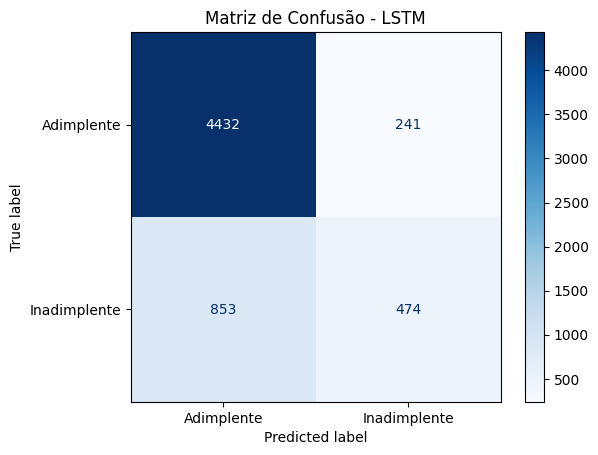

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Obter predições (probabilidades)
y_pred_probs = model_lstm.predict(X_test_lstm)

# 2. Converter para classes (limiar padrão de 0.5)
y_pred = (y_pred_probs > 0.5).astype(int)

# 3. Cálculo do ROC-AUC
auc_final = roc_auc_score(y_test, y_pred_probs)

print(f"--- RESULTADOS FINAIS LSTM ---")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Adimplente', 'Inadimplente']))

# 4. Visualização da Matriz de Confusão para o seu Artigo
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Adimplente', 'Inadimplente'])
disp.plot(cmap='Blues')
print(f"ROC-AUC Score: {auc_final:.4f}")
plt.title('Matriz de Confusão - LSTM')
plt.show()

### 4-6 Volting Classifier

In [ ]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ('lr', log_model),
        ('rf', rf_model),
        ('xgb', xgb_model)
    ],
    voting='soft'
)

voting_model.fit(X_train_proc, y_train)

y_val_pred = voting_model.predict(X_val_proc)
y_val_prob = voting_model.predict_proba(X_val_proc)[:,1]

print("Voting Classifier")
print(classification_report(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))

Voting Classifier
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      4673
           1       0.58      0.49      0.53      1327

    accuracy                           0.81      6000
   macro avg       0.72      0.69      0.70      6000
weighted avg       0.80      0.81      0.80      6000

ROC-AUC: 0.7700646388341627


### 5 Avaliação final de desempenho

### 5-1 Avaliação dos modelos

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score, accuracy_score

def avaliar_modelo(nome_modelo, model, X, y):
    # Para modelos Keras (como LSTM), model.predict(X) já retorna probabilidades
    if nome_modelo == "LSTM":
        y_prob = model.predict(X).flatten()  # Flatten para garantir 1D
        y_pred = (y_prob > 0.5).astype(int)
    else:
        y_pred = model.predict(X)
        y_prob = model.predict_proba(X)[:, 1]

    print(f"\n--- {nome_modelo} ---")
    print(classification_report(y, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y, y_prob):.3f}")

def metricas(model, X, y):
    # Esta função metricas é usada pelo DataFrame 'resultados' e não para o LSTM
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    return {
        'accuracy': accuracy_score(y, y_pred),
        'precision': precision_score(y, y_pred),
        'recall': recall_score(y, y_pred),
        'f1': f1_score(y, y_pred),
        'roc_auc': roc_auc_score(y, y_prob)
    }

avaliar_modelo("Logistic Regression", log_model, X_test_proc, y_test)
avaliar_modelo("SVM", svm_model, X_test_proc, y_test)
avaliar_modelo("Random Forest", rf_model, X_test_proc, y_test)
avaliar_modelo("XGBoost", xgb_model, X_test_proc, y_test)
avaliar_modelo("Voting", voting_model, X_test_proc, y_test)
avaliar_modelo("LSTM", model_lstm, X_test_lstm, y_test)


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.87      0.69      0.77      4673
           1       0.37      0.64      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000

ROC-AUC: 0.712

--- SVM ---
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      4673
           1       0.49      0.56      0.52      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.70      0.69      6000
weighted avg       0.79      0.78      0.78      6000

ROC-AUC: 0.751

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4673
           1       0.65      0.34      0.44      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score

def metricas(model, X, y):
    # Verifica se o modelo tem o atributo 'predict_proba' (comum em modelos sklearn)
    if hasattr(model, 'predict_proba'):
        y_pred = model.predict(X)
        y_prob = model.predict_proba(X)[:, 1]
    else: # Assume que é um modelo Keras (como LSTM)
        # Para modelos Keras com saída sigmoid, model.predict() retorna as probabilidades
        y_prob = model.predict(X).flatten() # .flatten() para garantir que seja 1D
        # Converte probabilidades em classes binárias (limiar de 0.5)
        y_pred = (y_prob > 0.5).astype(int)

    report = classification_report(y, y_pred, output_dict=True)
    auc_score = roc_auc_score(y, y_prob)

    return {
        'accuracy': report['accuracy'],
        'precision_0': report['0']['precision'],
        'recall_0': report['0']['recall'],
        'f1_0': report['0']['f1-score'],
        'precision_1': report['1']['precision'],
        'recall_1': report['1']['recall'],
        'f1_1': report['1']['f1-score'],
        'roc_auc': auc_score
    }

resultados = pd.DataFrame({
    "Logistic": metricas(log_model, X_test_proc, y_test),
    "SVM": metricas(svm_model, X_test_proc, y_test),
    "RandomForest": metricas(rf_model, X_test_proc, y_test),
    "XGBoost": metricas(xgb_model, X_test_proc, y_test),
    "Voting": metricas(voting_model, X_test_proc, y_test),
    "LSTM": metricas(model_lstm, X_test_lstm, y_test)
}).T

print(resultados)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              accuracy  precision_0  recall_0      f1_0  precision_1  \
Logistic      0.675667     0.869012  0.687139  0.767447     0.365727   
SVM           0.775000     0.869469  0.836722  0.852781     0.492349   
RandomForest  0.812500     0.833961  0.947999  0.887331     0.646802   
XGBoost       0.755000     0.861757  0.816392  0.838462     0.454545   
Voting        0.799333     0.856087  0.892360  0.873847     0.554473   
LSTM          0.817667     0.838600  0.948427  0.890139     0.662937   

              recall_1      f1_1   roc_auc  
Logistic      0.635268  0.464207  0.711627  
SVM           0.557649  0.522968  0.751290  
RandomForest  0.335343  0.441687  0.756315  
XGBoost       0.538809  0.493103  0.746276  
Voting        0.471741  0.509772  0.757401  
LSTM          0.357197  0.464251  0.772702  


188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


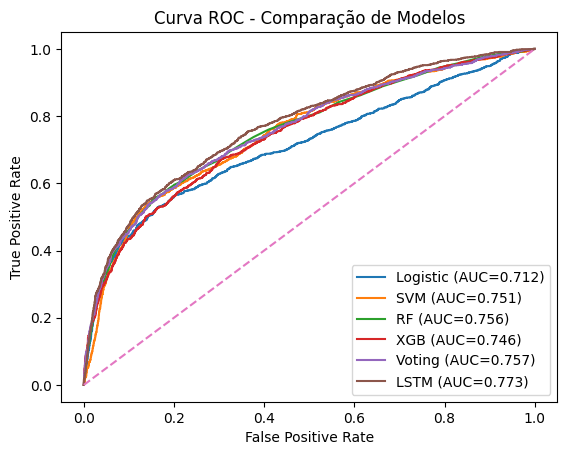

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_multiplos(modelos, X_proc, X_lstm, y):
    plt.figure()

    for nome, model in modelos.items():
        current_X = X_proc # Default para modelos Scikit-learn
        if nome == "LSTM": # Se for o modelo LSTM, usa X_lstm
            current_X = X_lstm

        if hasattr(model, 'predict_proba'): # Para modelos Scikit-learn
            y_prob = model.predict_proba(current_X)[:,1]
        else: # Para modelos Keras (como LSTM)
            y_prob = model.predict(current_X).flatten() # O predict do Keras já retorna probabilidades

        fpr, tpr, _ = roc_curve(y, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f'{nome} (AUC={roc_auc:.3f})')

    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Curva ROC - Comparação de Modelos')
    plt.legend()
    plt.show()

modelos = {
    "Logistic": log_model,
    "SVM": svm_model,
    "RF": rf_model,
    "XGB": xgb_model,
    "Voting": voting_model,
    "LSTM": model_lstm
}

plot_roc_multiplos(modelos, X_test_proc, X_test_lstm, y_test)

Modelos possuem boa capacidade de separação entre adimplentes e inadimplentes. O LSTM no geral tem melhor AUC de 0,773, em seguida vem os modelos Voting e Radom Forest.

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


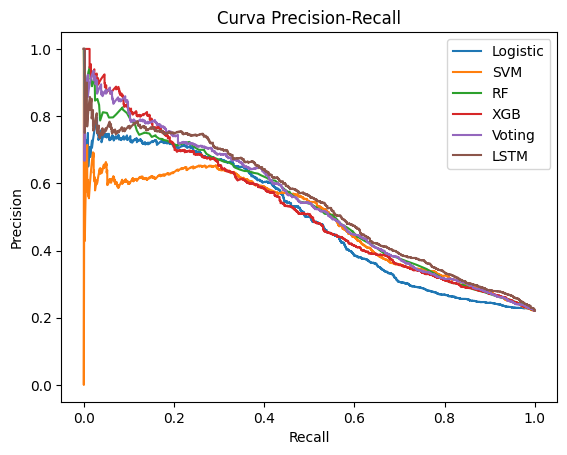

In [ ]:
from sklearn.metrics import precision_recall_curve

def plot_pr_multiplos(modelos, X_proc, X_lstm, y):
    plt.figure()

    for nome, model in modelos.items():
        current_X = X_proc # Default para modelos Scikit-learn
        if nome == "LSTM": # Se for o modelo LSTM, usa X_lstm
            current_X = X_lstm

        if hasattr(model, 'predict_proba'): # Para modelos Scikit-learn
            y_prob = model.predict_proba(current_X)[:,1]
        else: # Para modelos Keras (como LSTM)
            y_prob = model.predict(current_X).flatten() # O predict do Keras já retorna probabilidades

        precision, recall, _ = precision_recall_curve(y, y_prob)

        plt.plot(recall, precision, label=nome)

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curva Precision-Recall')
    plt.legend()
    plt.show()

plot_pr_multiplos(modelos, X_test_proc, X_test_lstm, y_test)

Esse indicador evidencia o desempenho de modelos com classes minoritarias. O modelo SVM tem o melhor equilibrio entre precisão e recall ao longo da curva.

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


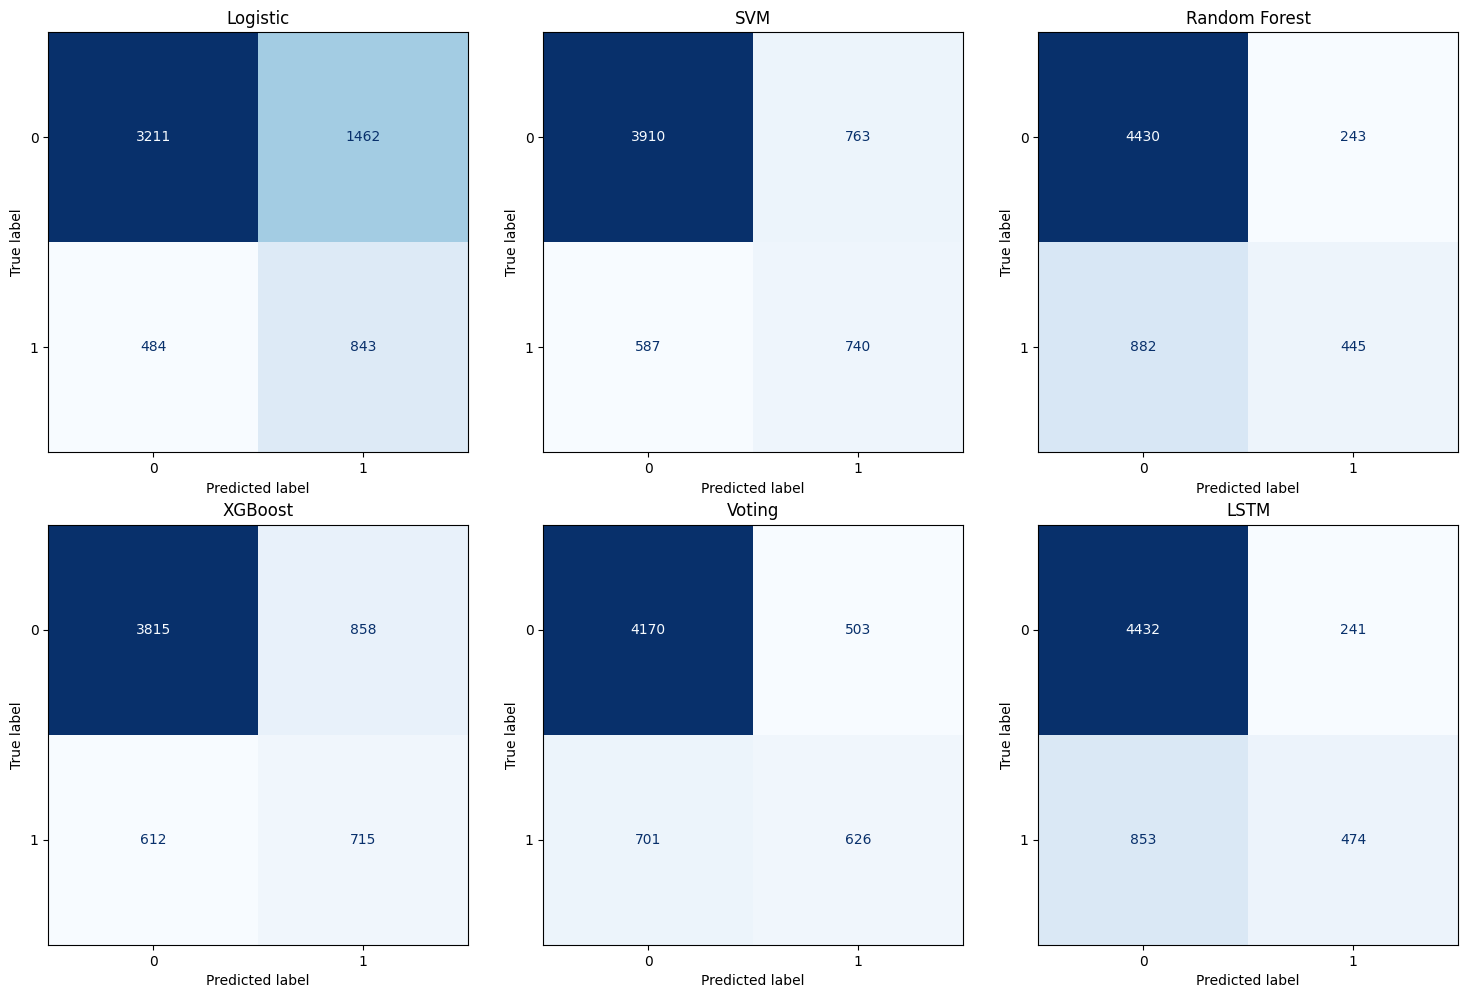

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrices(modelos, X_proc, X_lstm, y):
    n = len(modelos)
    cols = 3
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(15, 5 * rows))

    for i, (nome, model) in enumerate(modelos.items()):
        current_X = X_proc # Default para modelos Scikit-learn
        if nome == "LSTM": # Se for o modelo LSTM, usa X_lstm
            current_X = X_lstm

        # Para modelos Keras, o predict retorna probabilidades, que precisam ser limiarizadas
        if hasattr(model, 'predict_proba'): # Modelos Scikit-learn
            y_pred = model.predict(current_X)
        else: # Modelos Keras
            y_pred_proba = model.predict(current_X).flatten()
            y_pred = (y_pred_proba > 0.5).astype(int)

        cm = confusion_matrix(y, y_pred)

        ax = plt.subplot(rows, cols, i + 1)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=ax, cmap='Blues', colorbar=False)

        ax.set_title(nome)

    plt.tight_layout()
    plt.show()

modelos = {
    "Logistic": log_model,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "Voting": voting_model,
    "LSTM": model_lstm
}

plot_confusion_matrices(modelos, X_test_proc, X_test_lstm, y_test)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


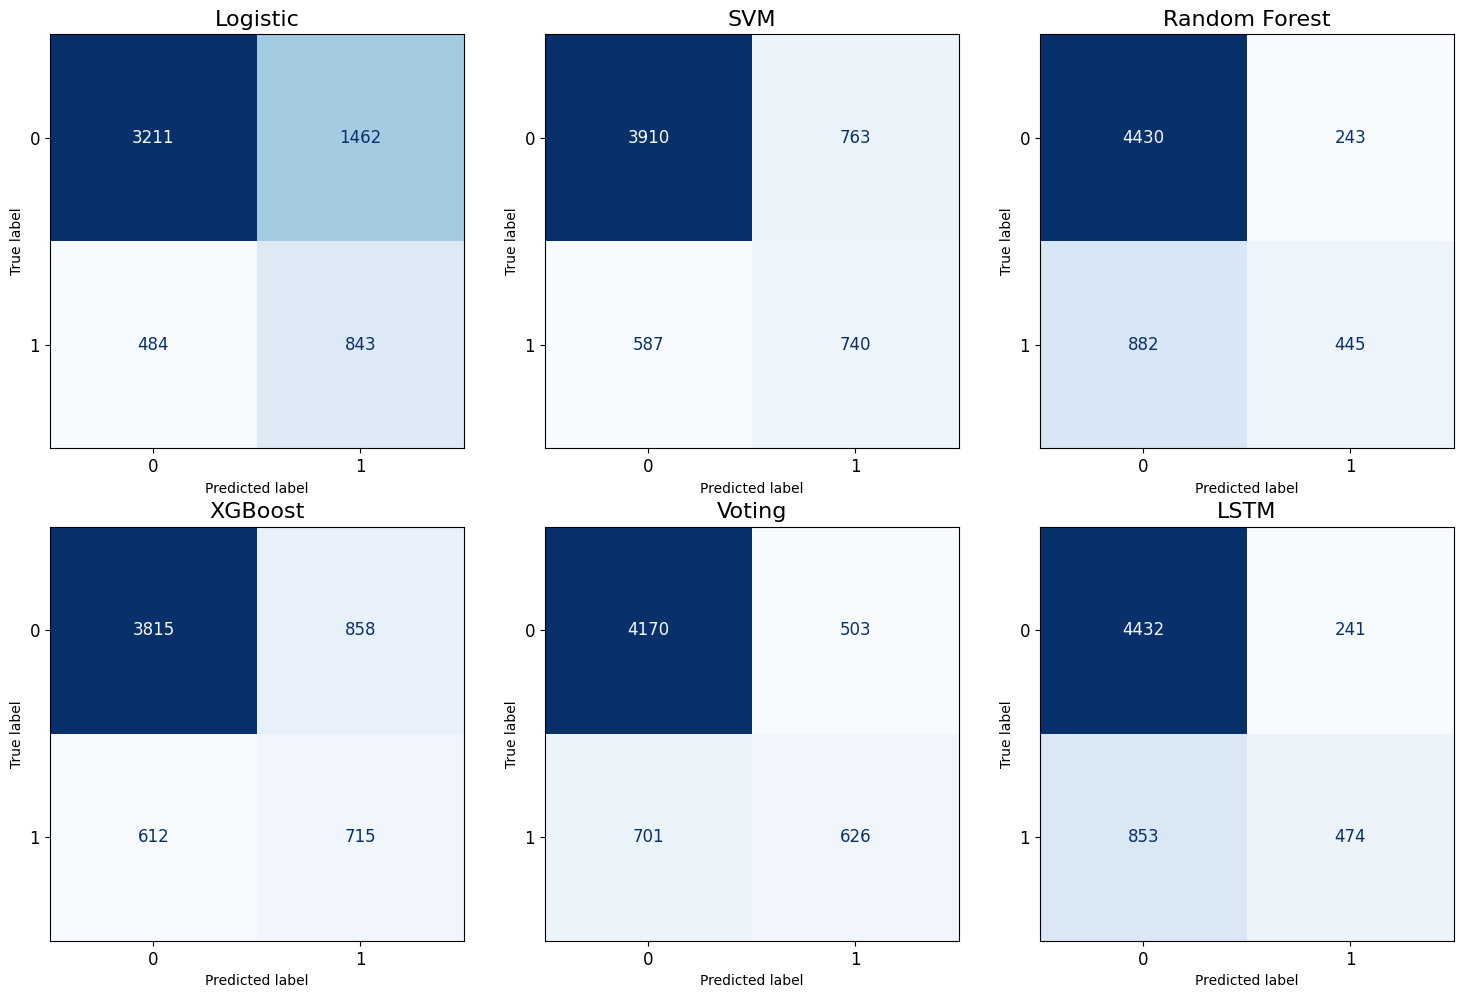

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrices(modelos, X_proc, X_lstm, y):
    n = len(modelos)
    cols = 3
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(15, 5 * rows))

    for i, (nome, model) in enumerate(modelos.items()):
        current_X = X_proc  # Default para modelos Scikit-learn
        if nome == "LSTM":  # Se for o modelo LSTM, usa X_lstm
            current_X = X_lstm

        # Para modelos Keras, o predict retorna probabilidades, que precisam ser limiarizadas
        if hasattr(model, 'predict_proba'):  # Modelos Scikit-learn
            y_pred = model.predict(current_X)
        else:  # Modelos Keras
            y_pred_proba = model.predict(current_X).flatten()
            y_pred = (y_pred_proba > 0.5).astype(int)

        cm = confusion_matrix(y, y_pred)

        ax = plt.subplot(rows, cols, i + 1)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=ax, cmap='Blues', colorbar=False)

        # 🔽 AUMENTO DE FONTE
        ax.set_title(nome, fontsize=16)
        ax.tick_params(axis='both', labelsize=12)

        # Ajusta tamanho dos números dentro da matriz
        for text in disp.text_.ravel():
            text.set_fontsize(12)

    plt.tight_layout()
    plt.show()

modelos = {
    "Logistic": log_model,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "Voting": voting_model,
    "LSTM": model_lstm
}

plot_confusion_matrices(modelos, X_test_proc, X_test_lstm, y_test)

* **O Modelo Campeão:** O algoritmo **SVM (Support Vector Machine)** apresentou a melhor aderência ao objetivo do negócio com um **F1-Score de 0,523**, garantindo o equilíbrio mais seguro entre a confiabilidade da predição e o volume de inadimplentes capturados.
* **Trade-off de Redes Neurais:** O modelo LSTM alcançou a maior área sob a curva (ROC-AUC de 0,770) e ótima acurácia geral, porém penalizou severamente o *Recall* (0,386), deixando escapar muitos clientes de risco.

Em resumo, não existe melhor modelo em todos os aspectos mas o SVM tem o um equilibrio.